# Hidden-layer size discussion

Validation reward comparison for three hidden-layer configurations.

In [12]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'statistic' else NOTEBOOK_DIR
LOG_ROOT = PROJECT_ROOT / 'logs'
TAG = 'Reward/validation'
TOTAL_EPISODES = 10_000

RUNS = [
    {
        'name': '64 parameters in each hidden layer',
        'version': 'DQN v6.2',
        'path': LOG_ROOT / 'DQN_v6.2_variant_0',
        'color': 'tab:blue',
    },
    {
        'name': '128 parameters in each hidden layer',
        'version': 'DQN v6.21',
        'path': LOG_ROOT / 'DQN_v6.21_variant_0',
        'color': 'tab:orange',
    },
    {
        'name': '32 parameters in each hidden layer',
        'version': 'DQN v8.4.2',
        'path': LOG_ROOT / 'DQN_v8.4.2_variant_0',
        'color': 'tab:green',
    },
]

In [13]:
def read_scalar_series(run_path: Path, tag: str, max_step: int | None = None):
    if not run_path.exists():
        raise FileNotFoundError(f'Missing TensorBoard log directory: {run_path}')

    accumulator = EventAccumulator(str(run_path), size_guidance={'scalars': 0})
    accumulator.Reload()
    scalar_tags = accumulator.Tags().get('scalars', [])
    if tag not in scalar_tags:
        raise KeyError(f'Tag {tag!r} not found in {run_path}. Available tags: {scalar_tags}')

    series = [(point.step, point.value) for point in accumulator.Scalars(tag)]
    if max_step is not None:
        series = [(step, value) for step, value in series if step <= max_step]
    return series


curves = []
for run in RUNS:
    series = read_scalar_series(run['path'], TAG, TOTAL_EPISODES)
    best_step, best_value = max(series, key=lambda item: item[1])
    curves.append({**run, 'series': series, 'best_step': best_step, 'best_value': best_value})
    print(f"{run['version']} ({run['name']}): {len(series)} validation points")

DQN v6.2 (64 parameters in each hidden layer): 100 validation points
DQN v6.21 (128 parameters in each hidden layer): 100 validation points
DQN v8.4.2 (32 parameters in each hidden layer): 100 validation points


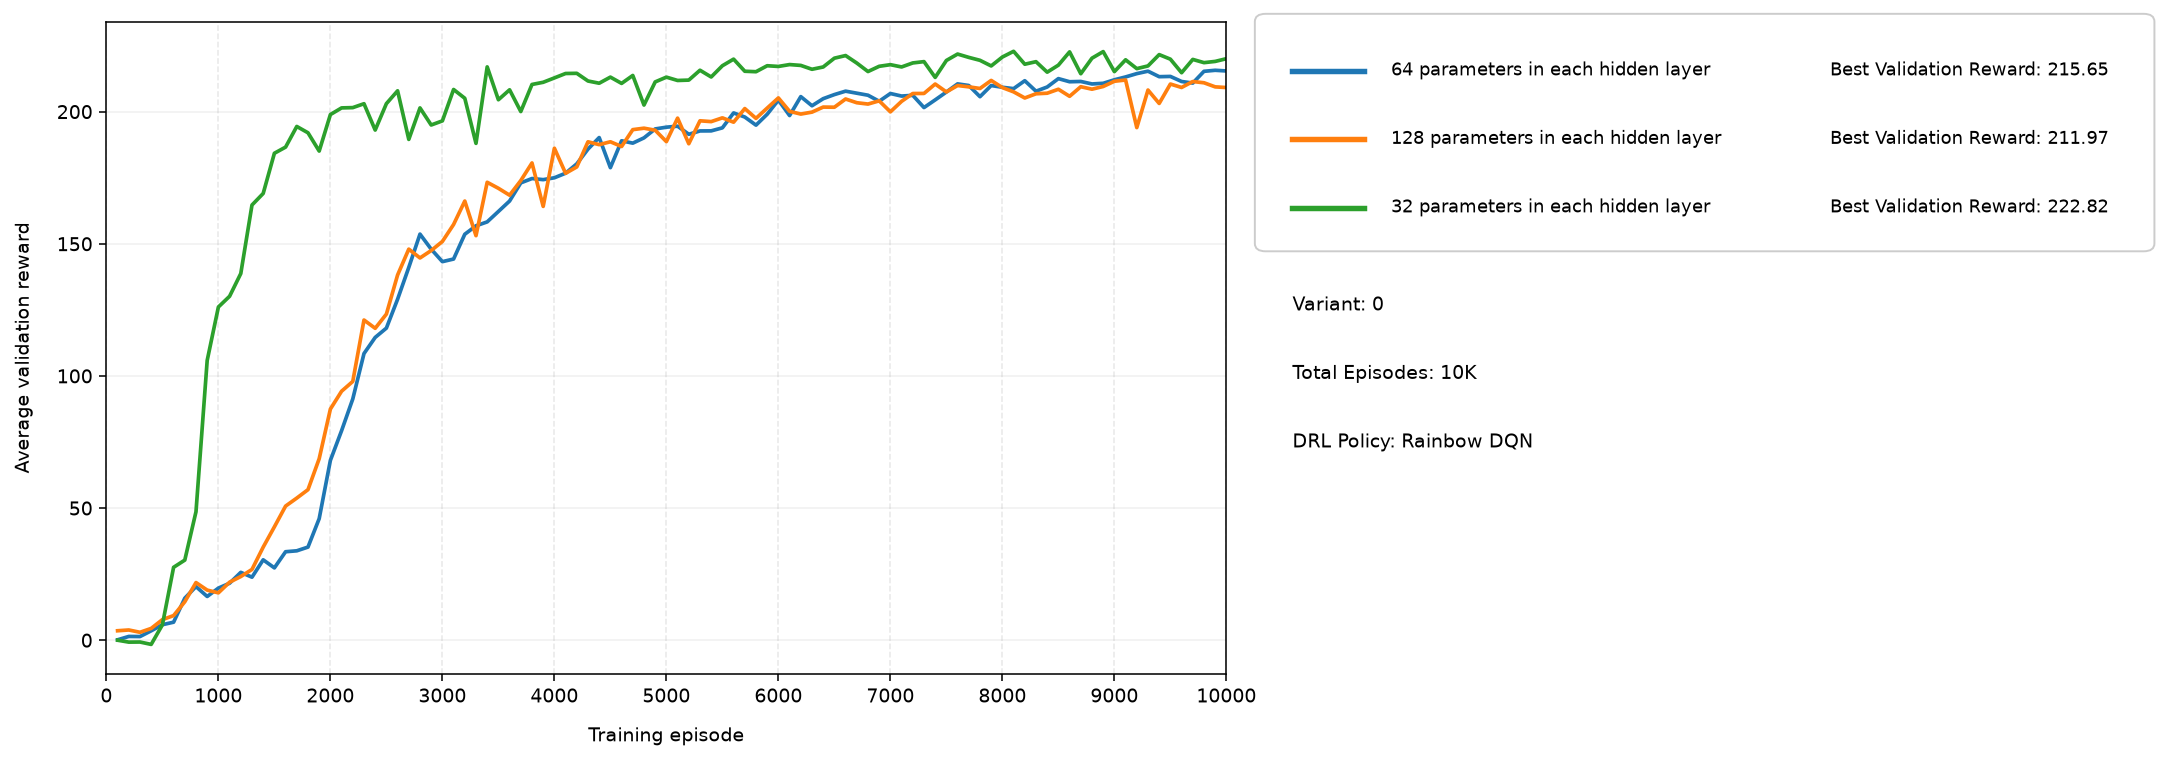

In [14]:
axis_width = 8.0
right_panel_width = 6.4
left_margin_width = 1.25
panel_gap_width = 0.28
height = 5.6
fig_width = left_margin_width + axis_width + panel_gap_width + right_panel_width
fig = plt.figure(figsize=(fig_width, height), dpi=140)

bottom_margin = 0.72
top_margin = 0.22
plot_height = height - bottom_margin - top_margin
ax = fig.add_axes([
    left_margin_width / fig_width, bottom_margin / height,
    axis_width / fig_width, plot_height / height,
])
legend_ax = fig.add_axes([
    (left_margin_width + axis_width + panel_gap_width) / fig_width,
    bottom_margin / height, right_panel_width / fig_width, plot_height / height,
])
legend_ax.axis('off')

for curve in curves:
    steps = [step for step, _ in curve['series']]
    values = [value for _, value in curve['series']]
    ax.plot(steps, values, color=curve['color'], linewidth=1.9)

legend_x = 0.03
legend_y = 0.98
line_width = 0.08
text_x = legend_x + line_width + 0.03
best_x = 0.63
row_gap = 0.105
legend_height = row_gap * len(curves) + 0.025
legend_box = FancyBboxPatch(
    (0.0, legend_y - legend_height + 0.02), 0.98, legend_height,
    boxstyle='round,pad=0.012', facecolor='white', edgecolor='0.8',
    transform=legend_ax.transAxes, clip_on=False, zorder=10,
)
legend_ax.add_patch(legend_box)

current_y = legend_y - 0.055
for curve in curves:
    legend_ax.plot(
        [legend_x, legend_x + line_width], [current_y, current_y],
        transform=legend_ax.transAxes, color=curve['color'],
        linewidth=2.8, clip_on=False, zorder=11,
    )
    legend_ax.text(
        text_x, current_y, f"{curve['name']}",
        transform=legend_ax.transAxes, ha='left', va='center',
        fontsize=9.5, zorder=11,
    )
    legend_ax.text(
        best_x, current_y, f"Best Validation Reward: {curve['best_value']:.2f}",
        transform=legend_ax.transAxes, ha='left', va='center',
        fontsize=9.5, zorder=11,
    )
    current_y -= row_gap

info_y = legend_y - legend_height - 0.060
info_lines = [
    'Variant: 0',
    'Total Episodes: 10K',
    'DRL Policy: Rainbow DQN',
]
for line_idx, info_line in enumerate(info_lines):
    legend_ax.text(
        legend_x, info_y - 0.105 * line_idx, info_line,
        transform=legend_ax.transAxes, ha='left', va='top', fontsize=10,
    )

ax.set_xlabel('Training episode', labelpad=10)
ax.set_ylabel('Average validation reward', labelpad=12)
ax.set_xlim(0, TOTAL_EPISODES)
ax.set_xticks(range(0, TOTAL_EPISODES + 1, 1000))
ax.grid(axis='x', linestyle='--', alpha=0.28)
ax.grid(axis='y', linestyle='-', alpha=0.18)
plt.show()